## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter

In [4]:
# Project directory
BASE_DIR = Path.cwd()

# Dataset directory
DATA_DIR = BASE_DIR / "hotels"

# Dataset paths
hotels_path = DATA_DIR / "hotels.csv"
stay_data_path = DATA_DIR / "stay_data.csv"
matched_hotels_path = DATA_DIR / "matched_hotels.csv"
city_data_path = DATA_DIR / "city_data.csv"

# Load datasets
hotels = pd.read_csv(hotels_path)
stay_data = pd.read_csv(stay_data_path)
matched_hotels = pd.read_csv(matched_hotels_path)
city_data = pd.read_csv(city_data_path)

In [5]:
print("hotels:", hotels.shape)
print("stay_data:", stay_data.shape)
print("matched_hotels:", matched_hotels.shape)
print("city_data:", city_data.shape)

hotels: (6000, 29)
stay_data: (3394, 10)
matched_hotels: (3375, 31)
city_data: (1221, 3)


In [6]:
df = hotels.copy()

print("Original shape:", df.shape)

Original shape: (6000, 29)


In [7]:
df.head()

,address,city,country,crawl_date,hotel_brand,hotel_description,hotel_facilities,hotel_star_rating,image_count,latitude,...,room_type,similar_hotel,site_review_count,site_review_rating,site_stay_review_rating,sitename,special_tag,state,uniq_id,zone
0,"KHIRSU, 246147 Pauri, India – Great location -",pauri,India,2016-09-01,NaN,Khirsu By GMVN offers accommodation in Pauri. ...,Bathroom:Toilet paper|Linen|Towels|Bathroom|To...,NaN,3.0,30.123749,...,Economy Double Room,Hotel Mandakini,NaN,NaN,NaN,http://www.booking.com/,Share,Uttarakhand,a5ea72415f8007fcbe65759830fdd3d9,NaN
1,"Kaathadimattam, Balacola Post, NEAR Siva Tea F...",ooty,India,2016-09-01,NaN,"Situated in Ooty in the Tamil Nadu Region, 8 k...",Bathroom:Toilet paper|Linen|Towels|Bidet|Towel...,3 stars,NaN,11.329595,...,British Empire Chalet,Treebo Yantra Leisures|Western Valley Resorts|...,5,7.6,Location:8.5|Staff:8|Cleanliness:7.5|Comfort:7...,http://www.booking.com/,Share,Tamil Nadu,7e0b055417271bbd9dae902f3e231ed4,NaN
2,"PIPALKOTI, 246472 Pīpalkoti, India – Show map",pīpalkoti,India,2016-09-01,NaN,TRH Pipalkoti offers accommodation in Pīpalkot...,Bathroom:Toilet paper|Linen|Towels|Bathroom•Vi...,NaN,4.0,30.429540,...,Economy Double Room,TRH Joshimath (New),NaN,NaN,NaN,http://www.booking.com/,Share,Uttarakhand,72c0af09827bbb620365aa5df523ba1d,NaN
3,"1 KARIYIL HOUSE KUMARAKOM NORTH PO KOTTAYAM, 6...",kumarakom,India,2016-09-01,NaN,"Swasti house boat 2 is located in Kumarakom, 3...",Bathroom:Toilet paper|Towels|Bath|Shower•Bedro...,NaN,2.0,9.616057,...,Deluxe Room,NaN,NaN,NaN,NaN,http://www.booking.com/,Share,Kerala,eb6fd33d99aa4a8088caa8f3ecb08275,NaN
4,"Kavanattinkara, 686563 Kumarakom, India – Show...",kumarakom,India,2016-09-01,NaN,"Amrutham Houseboat 2 is set in Kumarakom, 5 km...",Bathroom:Toilet paper|Linen|Towels|Towels/Shee...,NaN,NaN,9.632854,...,Mobile Home,Mandala Beach House & Cottages,NaN,NaN,NaN,http://www.booking.com/,Share,Kerala,0814d9af7ad808863c04db8f30437c57,NaN


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   address                  5410 non-null   str    
 1   city                     5982 non-null   str    
 2   country                  6000 non-null   str    
 3   crawl_date               6000 non-null   str    
 4   hotel_brand              1312 non-null   str    
 5   hotel_description        5410 non-null   str    
 6   hotel_facilities         5410 non-null   str    
 7   hotel_star_rating        3075 non-null   str    
 8   image_count              3537 non-null   float64
 9   latitude                 6000 non-null   float64
 10  locality                 529 non-null    str    
 11  longitude                6000 non-null   float64
 12  pageurl                  6000 non-null   str    
 13  property_id              5410 non-null   float64
 14  property_name            5410 non-n

In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
address,5410,2059,"1 KARIYIL HOUSE KUMARAKOM NORTH PO KOTTAYAM, 6...",7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,5982,543,new delhi,309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,6000,1,India,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
crawl_date,6000,2,2016-09-01,4098,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hotel_brand,1312,29,OYO Rooms,902,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hotel_description,5410,2266,Sidd's Hospitality provides homely accommodati...,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hotel_facilities,5410,2140,Ski:Ski storage•Pets:Pets are not allowed.•Act...,243,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hotel_star_rating,3075,10,3-star hotel,1148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
image_count,3537.0,NaN,NaN,NaN,24.317218,11.177179,1.0,17.0,24.0,30.0,57.0
latitude,6000.0,NaN,NaN,NaN,21.349458,7.348339,8.082004,15.007242,22.472682,28.395414,34.630544


In [10]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 0


In [11]:
missing = df.isna().sum().sort_values(ascending=False)
missing

zone                       5471
locality                   5471
province                   5471
hotel_brand                4688
site_stay_review_rating    3837
hotel_star_rating          2925
image_count                2463
site_review_count          1798
similar_hotel              1755
site_review_rating         1208
property_id                 590
special_tag                 590
room_count                  590
address                     590
hotel_facilities            590
hotel_description           590
property_name               590
state                        49
city                         18
room_type                     5
property_type                 0
pageurl                       0
qts                           0
longitude                     0
latitude                      0
crawl_date                    0
sitename                      0
country                       0
uniq_id                       0
dtype: int64

In [12]:
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)
missing_percent

zone                       91.183333
locality                   91.183333
province                   91.183333
hotel_brand                78.133333
site_stay_review_rating    63.950000
hotel_star_rating          48.750000
image_count                41.050000
site_review_count          29.966667
similar_hotel              29.250000
site_review_rating         20.133333
property_id                 9.833333
special_tag                 9.833333
room_count                  9.833333
address                     9.833333
hotel_facilities            9.833333
hotel_description           9.833333
property_name               9.833333
state                       0.816667
city                        0.300000
room_type                   0.083333
property_type               0.000000
pageurl                     0.000000
qts                         0.000000
longitude                   0.000000
latitude                    0.000000
crawl_date                  0.000000
sitename                    0.000000
c

In [13]:
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

missing_table

,missing_count,missing_percent
zone,5471,91.183333
locality,5471,91.183333
province,5471,91.183333
hotel_brand,4688,78.133333
site_stay_review_rating,3837,63.950000
hotel_star_rating,2925,48.750000
image_count,2463,41.050000
site_review_count,1798,29.966667
similar_hotel,1755,29.250000
site_review_rating,1208,20.133333


In [14]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

df.columns.tolist()

['address',
 'city',
 'country',
 'crawl_date',
 'hotel_brand',
 'hotel_description',
 'hotel_facilities',
 'hotel_star_rating',
 'image_count',
 'latitude',
 'locality',
 'longitude',
 'pageurl',
 'property_id',
 'property_name',
 'property_type',
 'province',
 'qts',
 'room_count',
 'room_type',
 'similar_hotel',
 'site_review_count',
 'site_review_rating',
 'site_stay_review_rating',
 'sitename',
 'special_tag',
 'state',
 'uniq_id',
 'zone']

In [15]:
df["hotel_star_rating"] = (
    df["hotel_star_rating"]
    .astype("string")
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
    .astype(float)
)

In [16]:
df["hotel_star_rating"].value_counts(dropna=False).sort_index()

hotel_star_rating
1.0     231
2.0     705
3.0    1408
4.0     427
5.0     304
NaN    2925
Name: count, dtype: int64

In [17]:
df["hotel_star_rating"].describe()

count    3075.000000
mean        2.957073
std         1.030809
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         5.000000
Name: hotel_star_rating, dtype: float64

In [18]:
df["site_review_count"] = pd.to_numeric(
    df["site_review_count"],
    errors="coerce"
)

In [19]:
df["site_review_count"].describe()

count    4171.000000
mean       73.589307
std       115.709486
min         5.000000
25%        11.000000
50%        30.000000
75%        81.000000
max       966.000000
Name: site_review_count, dtype: float64

In [20]:
df["site_review_rating"] = pd.to_numeric(
    df["site_review_rating"],
    errors="coerce"
)

df["site_review_rating"].describe()

count    4792.000000
mean        7.286269
std         1.203548
min         3.200000
25%         6.600000
50%         7.400000
75%         8.200000
max         9.900000
Name: site_review_rating, dtype: float64

In [21]:
def parse_stay_rating(value):
    if pd.isna(value):
        return {}

    result = {}
    parts = str(value).split("|")

    for part in parts:
        if ":" in part:
            key, score = part.rsplit(":", 1)
            key = key.strip().lower().replace(" ", "_")

            try:
                result[key] = float(score)
            except ValueError:
                pass

    return result

In [22]:
stay_ratings = df["site_stay_review_rating"].apply(parse_stay_rating)
stay_ratings_df = pd.DataFrame(stay_ratings.tolist(), index=df.index)

stay_ratings_df.head()

,location,staff,cleanliness,comfort,value_for_money,facilities,free_wifi,host,paid_wifi,total
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8.5,8.0,7.5,7.5,7.5,6.5,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df = pd.concat([df, stay_ratings_df], axis=1)

df.columns.tolist()

['address',
 'city',
 'country',
 'crawl_date',
 'hotel_brand',
 'hotel_description',
 'hotel_facilities',
 'hotel_star_rating',
 'image_count',
 'latitude',
 'locality',
 'longitude',
 'pageurl',
 'property_id',
 'property_name',
 'property_type',
 'province',
 'qts',
 'room_count',
 'room_type',
 'similar_hotel',
 'site_review_count',
 'site_review_rating',
 'site_stay_review_rating',
 'sitename',
 'special_tag',
 'state',
 'uniq_id',
 'zone',
 'location',
 'staff',
 'cleanliness',
 'comfort',
 'value_for_money',
 'facilities',
 'free_wifi',
 'host',
 'paid_wifi',
 'total']

In [24]:
df["hotel_facilities"].dropna().head()

0    Bathroom:Toilet paper|Linen|Towels|Bathroom|To...
1    Bathroom:Toilet paper|Linen|Towels|Bidet|Towel...
2    Bathroom:Toilet paper|Linen|Towels|Bathroom•Vi...
3    Bathroom:Toilet paper|Towels|Bath|Shower•Bedro...
4    Bathroom:Toilet paper|Linen|Towels|Towels/Shee...
Name: hotel_facilities, dtype: str

In [25]:
df["hotel_facilities_clean"] = (
    df["hotel_facilities"]
    .fillna("")
    .apply(
        lambda x: [
            item.strip().lower()
            for item in str(x).split("|")
            if item.strip()
        ]
    )
)

In [26]:
df["hotel_facilities_clean"].head()

0    [bathroom:toilet paper, linen, towels, bathroo...
1    [bathroom:toilet paper, linen, towels, bidet, ...
2    [bathroom:toilet paper, linen, towels, bathroo...
3    [bathroom:toilet paper, towels, bath, shower•b...
4    [bathroom:toilet paper, linen, towels, towels/...
Name: hotel_facilities_clean, dtype: object

In [27]:
facility_counter = Counter(
    facility
    for facilities in df["hotel_facilities_clean"]
    for facility in facilities
)

top_facilities = pd.DataFrame(
    facility_counter.most_common(20),
    columns=["facility", "count"]
)

top_facilities

,facility,count
0,toilet,3139
1,fan,2597
2,car hire,2328
3,tour desk,2273
4,newspapers,2245
5,free toiletries,2197
6,ironing service,2138
7,dry cleaning,2131
8,bathroom,2001
9,safety deposit box,1988


In [28]:
df["crawl_date"] = pd.to_datetime(
    df["crawl_date"],
    errors="coerce"
)

df["qts"] = pd.to_datetime(
    df["qts"],
    errors="coerce",
    utc=True
)

df[["crawl_date", "qts"]].head()

,crawl_date,qts
0,2016-09-01,2016-09-01 11:52:38+00:00
1,2016-09-01,2016-09-01 11:52:38+00:00
2,2016-09-01,2016-09-01 11:52:38+00:00
3,2016-09-01,2016-09-01 11:52:38+00:00
4,2016-09-01,2016-09-01 11:52:38+00:00


In [29]:
print("Property types:\n")
print(df["property_type"].value_counts().head(20))

print("\nRoom types:\n")
print(df["room_type"].value_counts().head(20))

print("\nCities:\n")
print(df["city"].value_counts().head(20))

print("\nStates:\n")
print(df["state"].value_counts().head(20))

print("\nCountries:\n")
print(df["country"].value_counts().head(20))

Property types:

property_type
204                  2141
Hotel                1295
City                  590
206                   439
216                   238
208                   148
201                   145
222                   138
Homestay               88
215                    83
Resort                 71
Guest_house            70
Apartment              68
Bed_and_breakfast      64
218                    56
221                    54
213                    48
220                    40
Holiday_home           30
203                    26
Name: count, dtype: int64

Room types:

room_type
Deluxe Double Room                           981
Standard Double Room                         650
Budget Double Room                           292
Deluxe Double or Twin Room                   245
Deluxe Room                                  183
Superior Double Room                         142
Standard Double or Twin Room                 121
Super Deluxe Double Room                     111
Deluxe 

In [30]:
columns_to_drop = [
    "pageurl",
    "uniq_id",
    "sitename"
]

df = df.drop(columns=columns_to_drop)

In [31]:
print("Unique property IDs:", df["property_id"].nunique())
print("Unique property names:", df["property_name"].nunique())

df["property_name"].value_counts().head(20)

Unique property IDs: 2065
Unique property names: 2054


property_name
Hotel Seetal                                 12
Green Hotel                                   8
Hotel Surya                                   7
Sidd's Hospitality                            6
Deltin Suites                                 6
Lall Ji Tourist Resort                        6
Hotel Deep                                    6
Royal Heritage Tripura Castle                 6
Aapnni Hotel                                  6
High Bank Himalayan Retreat                   6
Lemon Tree Premier “The Atrium” Ahmedabad     6
The Sonnet                                    6
Hotel Good Night                              6
White Conch Residency                         6
Hotel Amrit Regency                           6
Mayur                                         6
Angel Residency                               6
Hotel Adi                                     6
Treebo Corporate Suites                       6
Hotel Kanha Continental                       6
Name: count, dtype: int64

In [32]:
df["property_id"] = pd.to_numeric(
    df["property_id"],
    errors="coerce"
).astype("Int64")

df["property_id"].dtype

Int64Dtype()

In [33]:
numeric_columns = df.select_dtypes(include=np.number).columns
print("Numerical columns:")
print(numeric_columns.tolist())

print("\nNumerical summary:")
display(df[numeric_columns].describe().T)

Numerical columns:
['hotel_star_rating', 'image_count', 'latitude', 'longitude', 'property_id', 'room_count', 'site_review_count', 'site_review_rating', 'location', 'staff', 'cleanliness', 'comfort', 'value_for_money', 'facilities', 'free_wifi', 'host', 'paid_wifi', 'total']

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
hotel_star_rating,3075.0,2.957073,1.030809,1.0,2.0,3.0,3.0,5.0
image_count,3537.0,24.317218,11.177179,1.0,17.0,24.0,30.0,57.0
latitude,6000.0,21.349458,7.348339,8.082004,15.007242,22.472682,28.395414,34.630544
longitude,6000.0,77.184569,3.990125,68.963419,74.314587,76.764852,78.093757,93.02006
property_id,5410.0,1282464.15915,547969.078033,482571.0,548208.0,1623448.0,1691273.0,1851397.0
room_count,5410.0,25.373383,31.66692,1.0,10.0,20.0,30.0,523.0
site_review_count,4171.0,73.589307,115.709486,5.0,11.0,30.0,81.0,966.0
site_review_rating,4792.0,7.286269,1.203548,3.2,6.6,7.4,8.2,9.9
location,2128.0,7.379041,1.205286,3.1,6.6,7.5,8.3,10.0
staff,2109.0,7.345804,1.290653,3.0,6.6,7.4,8.3,10.0


In [34]:
categorical_columns = df.select_dtypes(
    include=["object", "string"]
).columns

print("Categorical/text columns:")
print(categorical_columns.tolist())

Categorical/text columns:
['address', 'city', 'country', 'hotel_brand', 'hotel_description', 'hotel_facilities', 'locality', 'property_name', 'property_type', 'province', 'room_type', 'similar_hotel', 'site_stay_review_rating', 'special_tag', 'state', 'zone', 'hotel_facilities_clean']


In [35]:
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

missing_table

,missing_count,missing_percent
host,5962,99.366667
total,5911,98.516667
paid_wifi,5851,97.516667
zone,5471,91.183333
locality,5471,91.183333
province,5471,91.183333
hotel_brand,4688,78.133333
free_wifi,4557,75.950000
staff,3891,64.850000
location,3872,64.533333


In [36]:
invalid_stars = df.loc[
    ~df["hotel_star_rating"].isin([1, 2, 3, 4, 5])
    & df["hotel_star_rating"].notna(),
    "hotel_star_rating"
]

print("Invalid star ratings:")
print(invalid_stars.unique())

print("\nReview rating range:")
print(df["site_review_rating"].min(), df["site_review_rating"].max())

print("\nLatitude range:")
print(df["latitude"].min(), df["latitude"].max())

print("\nLongitude range:")
print(df["longitude"].min(), df["longitude"].max())

Invalid star ratings:
[]

Review rating range:
3.2 9.9

Latitude range:
8.08200387846947 34.63054409123111

Longitude range:
68.963419 93.02006006240843


In [37]:
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(exist_ok=True)

processed_path = PROCESSED_DIR / "hotels_clean.csv"
df.to_csv(processed_path, index=False)

print("Saved to:", processed_path)

Saved to: /Users/mahimjohn/Desktop/movie_project/hotels/processed/hotels_clean.csv


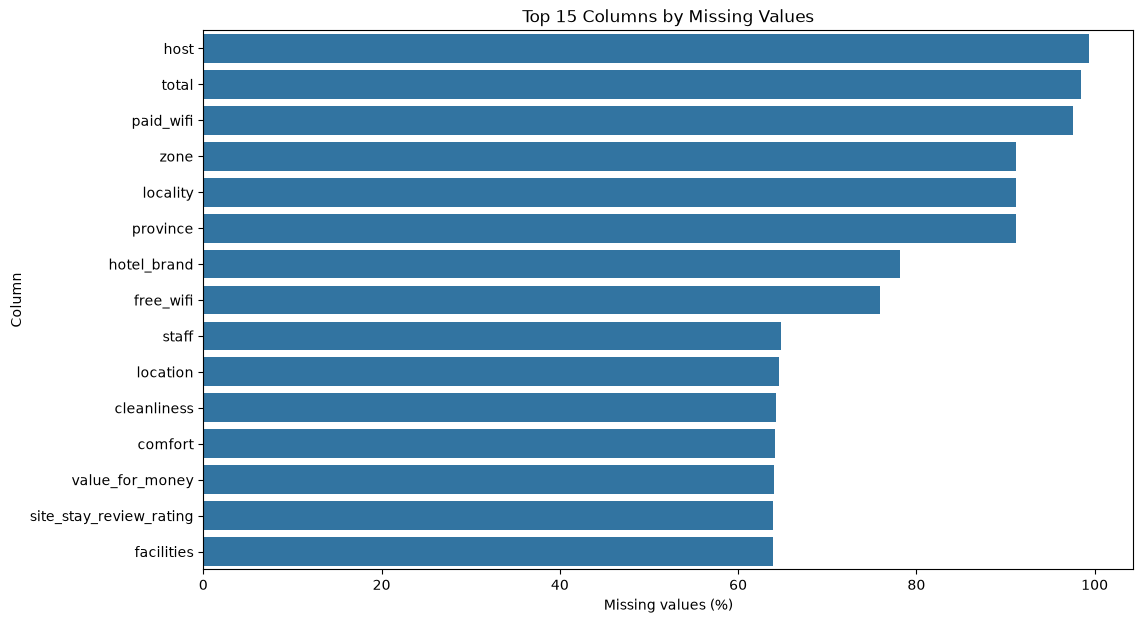

In [38]:
plt.figure(figsize=(12, 7))

missing_plot = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .head(15) * 100
)

sns.barplot(
    x=missing_plot.values,
    y=missing_plot.index
)

plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.title("Top 15 Columns by Missing Values")
plt.show()

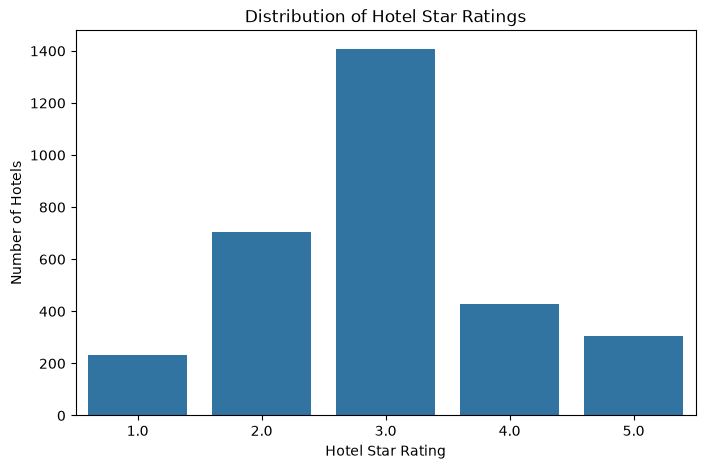

In [39]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="hotel_star_rating"
)

plt.xlabel("Hotel Star Rating")
plt.ylabel("Number of Hotels")
plt.title("Distribution of Hotel Star Ratings")
plt.show()

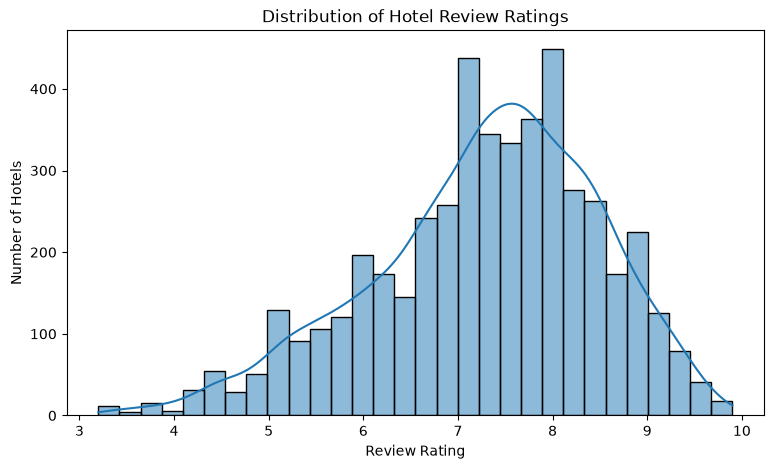

In [40]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="site_review_rating",
    bins=30,
    kde=True
)

plt.xlabel("Review Rating")
plt.ylabel("Number of Hotels")
plt.title("Distribution of Hotel Review Ratings")
plt.show()

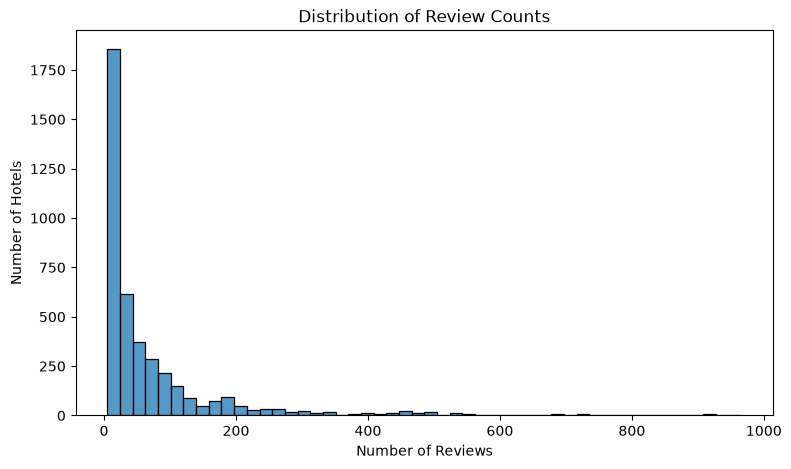

In [41]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="site_review_count",
    bins=50
)

plt.xlabel("Number of Reviews")
plt.ylabel("Number of Hotels")
plt.title("Distribution of Review Counts")
plt.show()

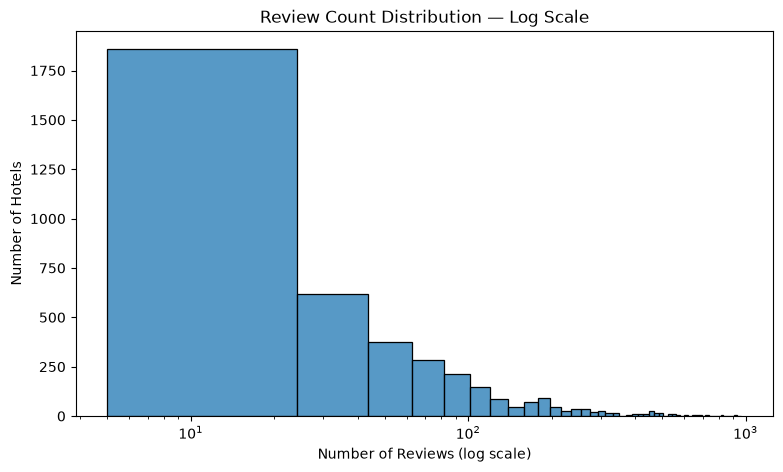

In [42]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="site_review_count",
    bins=50
)

plt.xscale("log")
plt.xlabel("Number of Reviews (log scale)")
plt.ylabel("Number of Hotels")
plt.title("Review Count Distribution — Log Scale")
plt.show()

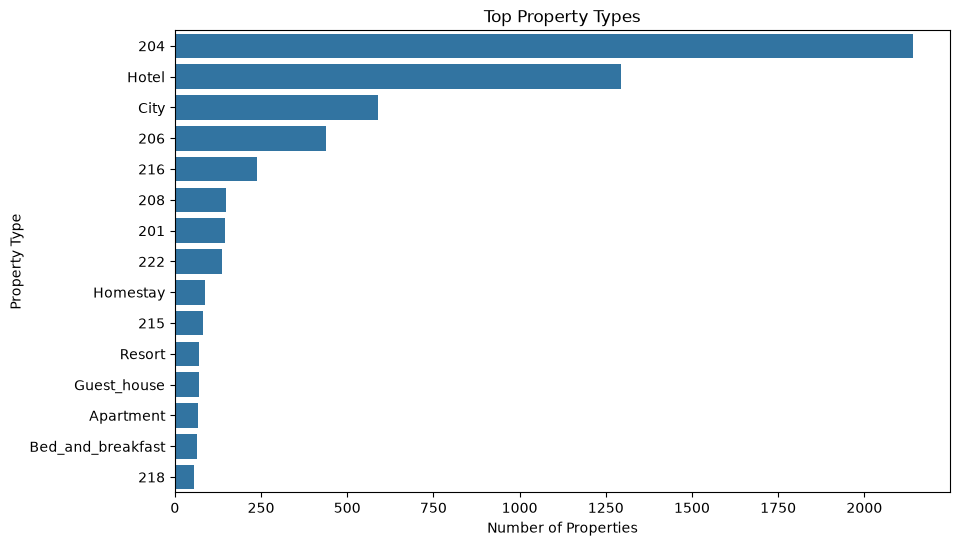

In [43]:
property_counts = df["property_type"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=property_counts.values, y=property_counts.index)
plt.xlabel("Number of Properties")
plt.ylabel("Property Type")
plt.title("Top Property Types")
plt.show()

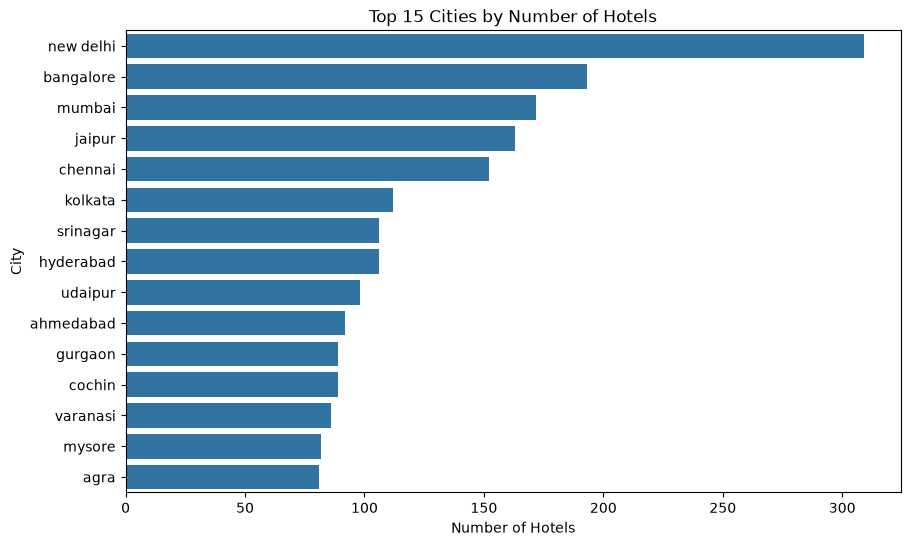

In [44]:
city_counts = df["city"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=city_counts.values, y=city_counts.index)
plt.xlabel("Number of Hotels")
plt.ylabel("City")
plt.title("Top 15 Cities by Number of Hotels")
plt.show()

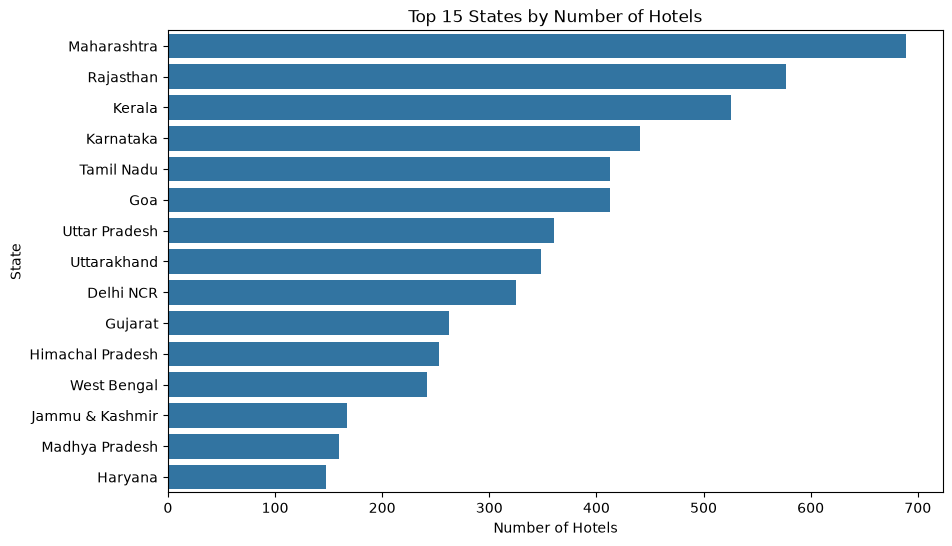

In [45]:
state_counts = df["state"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=state_counts.values, y=state_counts.index)
plt.xlabel("Number of Hotels")
plt.ylabel("State")
plt.title("Top 15 States by Number of Hotels")
plt.show()

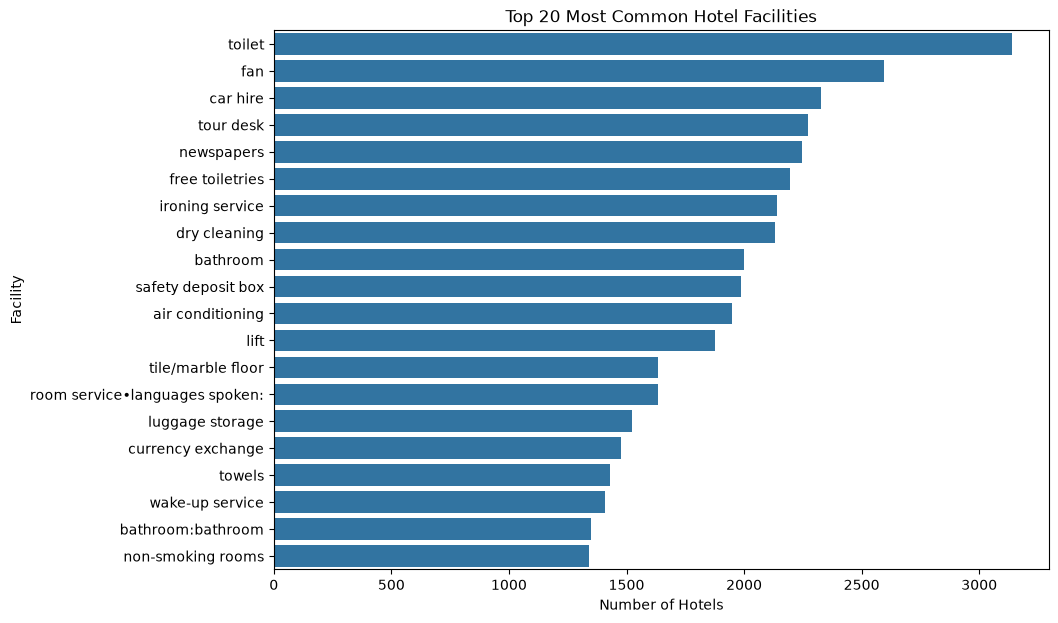

In [46]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_facilities,
    x="count",
    y="facility"
)

plt.xlabel("Number of Hotels")
plt.ylabel("Facility")
plt.title("Top 20 Most Common Hotel Facilities")
plt.show()

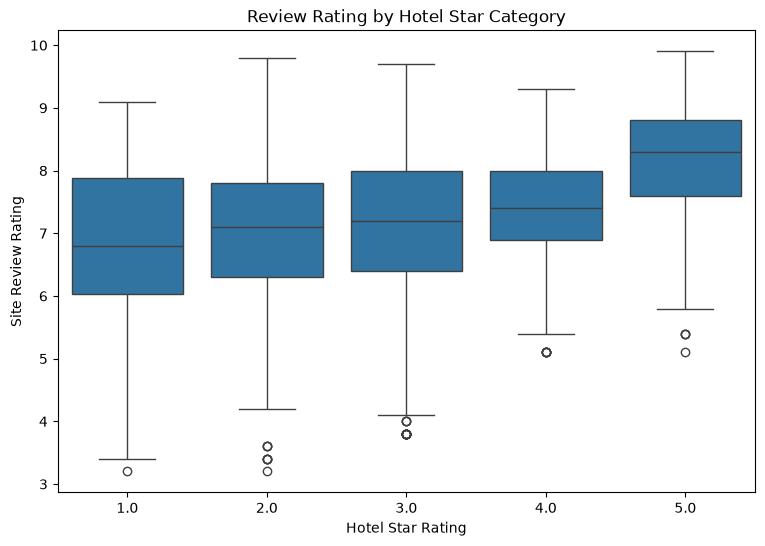

In [47]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="hotel_star_rating",
    y="site_review_rating"
)

plt.xlabel("Hotel Star Rating")
plt.ylabel("Site Review Rating")
plt.title("Review Rating by Hotel Star Category")
plt.show()

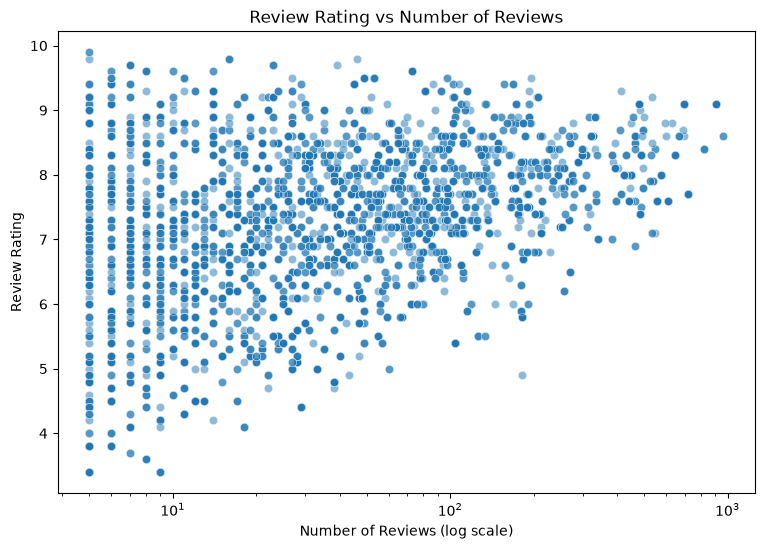

In [48]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="site_review_count",
    y="site_review_rating",
    alpha=0.5
)

plt.xscale("log")
plt.xlabel("Number of Reviews (log scale)")
plt.ylabel("Review Rating")
plt.title("Review Rating vs Number of Reviews")
plt.show()

In [49]:
eda_numeric = [
    "hotel_star_rating",
    "image_count",
    "latitude",
    "longitude",
    "room_count",
    "site_review_count",
    "site_review_rating"
]

correlation = df[eda_numeric].corr()
correlation

,hotel_star_rating,image_count,latitude,longitude,room_count,site_review_count,site_review_rating
hotel_star_rating,1.000000,0.217368,-0.039336,-0.053526,0.402451,0.079180,0.273887
image_count,0.217368,1.000000,0.053266,-0.008570,0.219310,0.026992,0.057512
latitude,-0.039336,0.053266,1.000000,0.052757,-0.010104,-0.038352,-0.118342
longitude,-0.053526,-0.008570,0.052757,1.000000,0.025392,-0.026493,-0.104619
room_count,0.402451,0.219310,-0.010104,0.025392,1.000000,0.097955,0.010040
site_review_count,0.079180,0.026992,-0.038352,-0.026493,0.097955,1.000000,0.283225
site_review_rating,0.273887,0.057512,-0.118342,-0.104619,0.010040,0.283225,1.000000


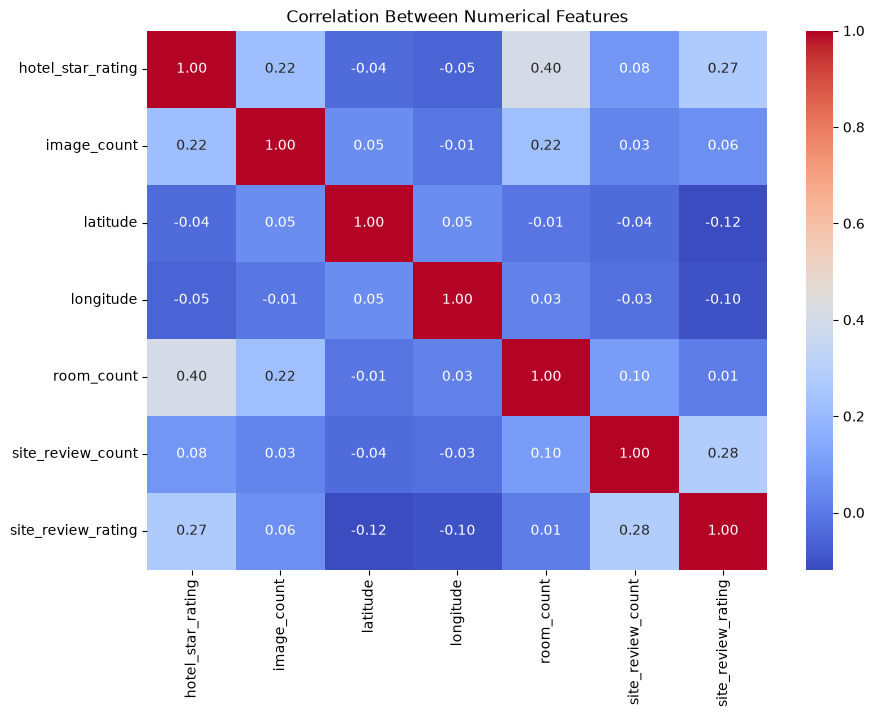

In [50]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Numerical Features")
plt.show()

In [51]:
property_rating = (
    df.groupby("property_type")["site_review_rating"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

property_rating.head(15)

,mean,count
property_type,,
212,8.720000,10
Boat,8.422222,9
Holiday_park,8.300000,3
223,8.280000,5
Villa,8.240000,10
Resort,8.193617,47
215,8.130233,43
222,8.086735,98
Bed_and_breakfast,7.960000,40


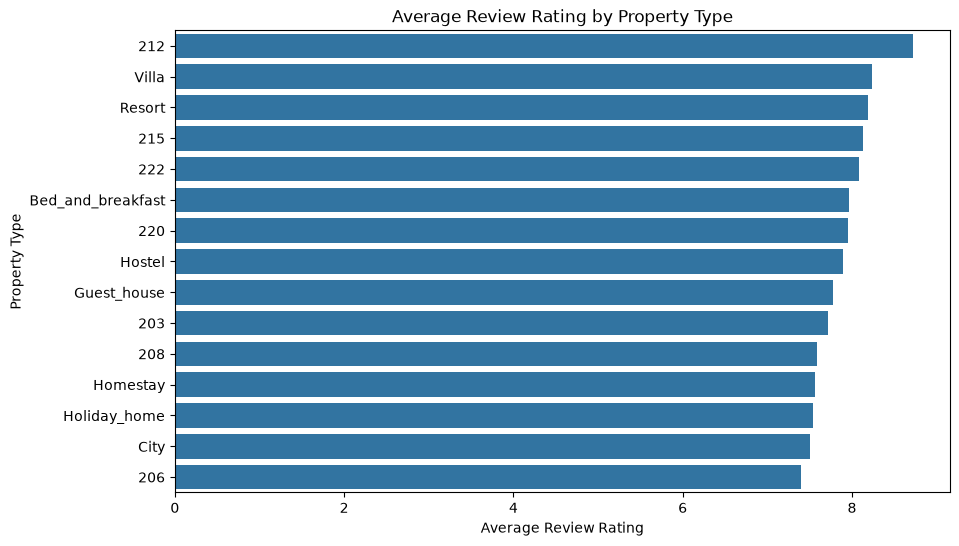

In [52]:
property_rating_filtered = property_rating[
    property_rating["count"] >= 10
].head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=property_rating_filtered["mean"],
    y=property_rating_filtered.index
)
plt.xlabel("Average Review Rating")
plt.ylabel("Property Type")
plt.title("Average Review Rating by Property Type")
plt.show()

In [53]:
city_rating = (
    df.groupby("city")["site_review_rating"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

city_rating_filtered = city_rating[
    city_rating["count"] >= 10
].head(15)

city_rating_filtered

,mean,count
city,,
jodhpur,8.438889,36
vagator,8.329412,17
varkala,8.311111,54
jaisalmer,8.304225,71
cochin,8.298718,78
mararikulam,8.245455,11
benaulim,8.170000,10
alleppey,8.161194,67
vythiri,8.160000,10


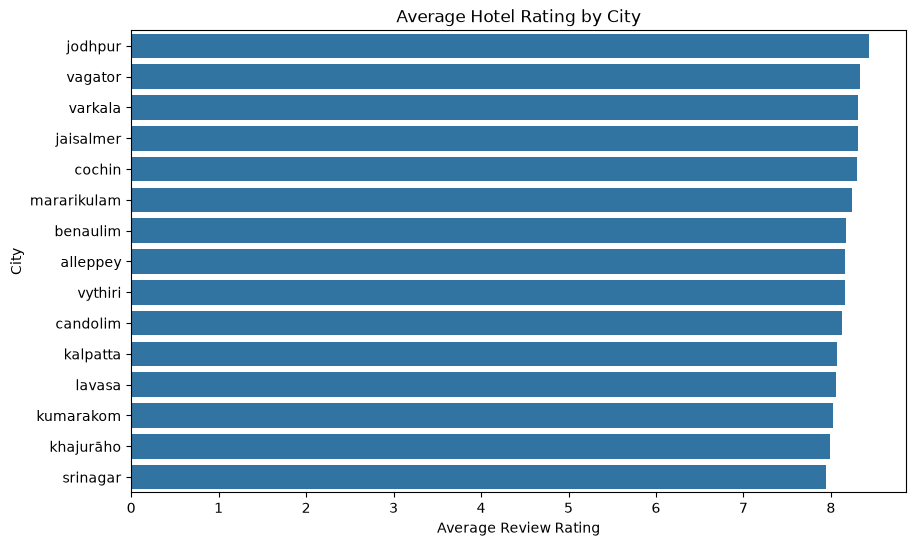

In [54]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=city_rating_filtered["mean"],
    y=city_rating_filtered.index
)

plt.xlabel("Average Review Rating")
plt.ylabel("City")
plt.title("Average Hotel Rating by City")
plt.show()

In [55]:
print("Final dataset shape:", df.shape)

print("\nNumerical columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical/text columns:")
print(df.select_dtypes(include=["object", "string"]).columns.tolist())

Final dataset shape: (6000, 37)

Numerical columns:
['hotel_star_rating', 'image_count', 'latitude', 'longitude', 'property_id', 'room_count', 'site_review_count', 'site_review_rating', 'location', 'staff', 'cleanliness', 'comfort', 'value_for_money', 'facilities', 'free_wifi', 'host', 'paid_wifi', 'total']

Categorical/text columns:
['address', 'city', 'country', 'hotel_brand', 'hotel_description', 'hotel_facilities', 'locality', 'property_name', 'property_type', 'province', 'room_type', 'similar_hotel', 'site_stay_review_rating', 'special_tag', 'state', 'zone', 'hotel_facilities_clean']


In [56]:
df.head()

,address,city,country,crawl_date,hotel_brand,hotel_description,hotel_facilities,hotel_star_rating,image_count,latitude,...,staff,cleanliness,comfort,value_for_money,facilities,free_wifi,host,paid_wifi,total,hotel_facilities_clean
0,"KHIRSU, 246147 Pauri, India – Great location -",pauri,India,2016-09-01,NaN,Khirsu By GMVN offers accommodation in Pauri. ...,Bathroom:Toilet paper|Linen|Towels|Bathroom|To...,NaN,3.0,30.123749,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[bathroom:toilet paper, linen, towels, bathroo..."
1,"Kaathadimattam, Balacola Post, NEAR Siva Tea F...",ooty,India,2016-09-01,NaN,"Situated in Ooty in the Tamil Nadu Region, 8 k...",Bathroom:Toilet paper|Linen|Towels|Bidet|Towel...,3.0,NaN,11.329595,...,8.0,7.5,7.5,7.5,6.5,NaN,NaN,NaN,NaN,"[bathroom:toilet paper, linen, towels, bidet, ..."
2,"PIPALKOTI, 246472 Pīpalkoti, India – Show map",pīpalkoti,India,2016-09-01,NaN,TRH Pipalkoti offers accommodation in Pīpalkot...,Bathroom:Toilet paper|Linen|Towels|Bathroom•Vi...,NaN,4.0,30.429540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[bathroom:toilet paper, linen, towels, bathroo..."
3,"1 KARIYIL HOUSE KUMARAKOM NORTH PO KOTTAYAM, 6...",kumarakom,India,2016-09-01,NaN,"Swasti house boat 2 is located in Kumarakom, 3...",Bathroom:Toilet paper|Towels|Bath|Shower•Bedro...,NaN,2.0,9.616057,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[bathroom:toilet paper, towels, bath, shower•b..."
4,"Kavanattinkara, 686563 Kumarakom, India – Show...",kumarakom,India,2016-09-01,NaN,"Amrutham Houseboat 2 is set in Kumarakom, 5 km...",Bathroom:Toilet paper|Linen|Towels|Towels/Shee...,NaN,NaN,9.632854,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[bathroom:toilet paper, linen, towels, towels/..."
